## 1. Importing the libraries

In [36]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

## 2. Configuration

In [72]:
# Dataset configuration
DATASET_PATH = "./KNN_Project_Data.csv"
TARGET_COLUMN = "TARGET CLASS"

# Train Test Split config
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Preprocessing config
SCALER = StandardScaler()

# Visualization config
FIGURE_SIZE = (10,10)
ALPHA = 0.6

# Model config
K_RANGE = range(1, 40)
K = 17
KNN_PARAMETERS = {
    "n_neighbors": K,
    "weights": "uniform",
    "metric": "minkowski"
}

## 3. Helper functions

In [38]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:,1]

    print("Accuracy score: ", accuracy_score(y_test, y_pred))

    print("\nROC AUC score: ", roc_auc_score(y_test, y_pred_proba))

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:\n", cm)

    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [39]:
def plot_correlation_heatmap(numerical_column):
    corr = df[numerical_column].corr()

    plt.figure(figsize=FIGURE_SIZE)

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm"
    )

    plt.title("Heatmap for correlation analysis")
    plt.show()

In [40]:
def plot_score_for_k(score):
    plt.figure(figsize=FIGURE_SIZE)
    
    plt.plot(range(1, len(score) + 1), score, marker="x")
        
    plt.xlabel("Number of neighbors (K)")
    plt.ylabel("Error Rate")
    plt.title("Elbow Method: Error Rate for multiple K values")

    plt.grid(True)
    plt.show()

In [41]:
def calculate_error_rate_score(X_train, X_test, y_train, y_test):
    error_rate = []

    for k in K_RANGE:
        knn_pipeline = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("knn", KNeighborsClassifier(n_neighbors=k))
            ]
        )

        knn_pipeline.fit(X_train, y_train)

        prediction = knn_pipeline.predict(X_test)

        error_rate.append(np.mean(prediction != y_test))

    plot_score_for_k(error_rate)

In [42]:
def plot_feature_importance(knn_model, X_test, y_test, feature_names):
    """
    Calculates and plots feature importance for a kNN model using Permutation Importance.
    
    Parameters:
    - knn_model: Your trained KNeighborsClassifier
    - X_test: Your scaled test data (NumPy array or DataFrame)
    - y_test: Your true test labels
    - feature_names: A list of the column names for your features
    """
        
    # n_repeats=10 means it shuffles each column 10 times to get a reliable average
    results = permutation_importance(knn_model, X_test, y_test, scoring='accuracy', 
                                     n_repeats=10, random_state=42)
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance_Mean': results.importances_mean,
        'Importance_Std': results.importances_std
    })
    
    importance_df = importance_df.sort_values(by='Importance_Mean', ascending=False)
    
    plt.figure(figsize=FIGURE_SIZE)
    
    sns.barplot(
        x='Importance_Mean', 
        y='Feature', 
        data=importance_df, 
        hue='Feature',
        palette='viridis',
        legend=False
    )
    
    plt.title('kNN Feature Importance (via Permutation)', fontsize=14, pad=15)
    plt.xlabel('Decrease in Accuracy when Feature is Shuffled', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=ALPHA)
    
    plt.tight_layout()
    plt.show()

In [43]:
def plot_roc_curve(model, X_test, y_test):
    y_scores = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=FIGURE_SIZE)

    plt.plot(fpr, tpr, label='Model ROC Curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0,1], [0,1], linestyle='--')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=ALPHA)
    plt.show()

In [44]:
def plot_calibration_curve(model, X_test, y_test, n_bins=10):
    """
    Plots the Calibration Curve (Actual vs Predicted Probabilities) for a Classifier.
    Use this for models like kNN, XGBoost, Logistic Regression, etc.
    """
    y_probs = model.predict_proba(X_test)[:, 1]
    
    prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=n_bins, strategy='uniform')
    
    plt.figure(figsize=(8, 6))
    
    plt.plot([0, 1], [0, 1], linestyle='--', color='darkgrey', label='Perfectly Calibrated')
    
    plt.plot(prob_pred, prob_true, marker='o', color='#1f77b4', lw=2, label='Model Calibration')
    
    plt.xlabel('Mean Predicted Probability', fontsize=12)
    plt.ylabel('Fraction of Actual Positives', fontsize=12)
    plt.title('Calibration Curve (Reliability Diagram)', fontsize=14, pad=15)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [86]:
def display_prediction_example(model, prediction_example):
    for example_name, example_data in prediction_example.items():
        prediction = model.predict(example_data)

        print(f"\nScenario : {example_name}")
        print("-" * 20)
        print(example_data)
        print(f"\nPrediction (Target Class): {prediction[0]}")

## 4. Loading the dataset

In [46]:
df = pd.read_csv(DATASET_PATH)

## 5. Understanding the dataset / Dataset overview 

In [47]:
df.shape

(1000, 11)

In [48]:
df.columns

Index(['XVPM', 'GWYH', 'TRAT', 'TLLZ', 'IGGA', 'HYKR', 'EDFS', 'GUUB', 'MGJM',
       'JHZC', 'TARGET CLASS'],
      dtype='str')

In [49]:
df.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


In [50]:
df.isnull().sum()

XVPM            0
GWYH            0
TRAT            0
TLLZ            0
IGGA            0
HYKR            0
EDFS            0
GUUB            0
MGJM            0
JHZC            0
TARGET CLASS    0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   XVPM          1000 non-null   float64
 1   GWYH          1000 non-null   float64
 2   TRAT          1000 non-null   float64
 3   TLLZ          1000 non-null   float64
 4   IGGA          1000 non-null   float64
 5   HYKR          1000 non-null   float64
 6   EDFS          1000 non-null   float64
 7   GUUB          1000 non-null   float64
 8   MGJM          1000 non-null   float64
 9   JHZC          1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [53]:
df.describe()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1055.071157,991.851567,1529.373525,495.107156,940.590072,1550.637455,1561.003252,561.346117,1089.067338,1452.521629,0.50000
std,370.980193,392.278890,640.286092,142.789188,345.923136,493.491988,598.608517,247.357552,402.666953,568.132005,0.50025
min,21.170000,21.720000,31.800000,8.450000,17.930000,27.930000,31.960000,13.520000,23.210000,30.890000,0.00000
25%,767.413366,694.859326,1062.600806,401.788135,700.763295,1219.267077,1132.097865,381.704293,801.849802,1059.499689,0.00000
50%,1045.904805,978.355081,1522.507269,500.197421,939.348662,1564.996551,1565.882879,540.420379,1099.087954,1441.554053,0.50000
75%,1326.065178,1275.528770,1991.128626,600.525709,1182.578166,1891.937040,1981.739411,725.762027,1369.923665,1864.405512,1.00000
max,2117.000000,2172.000000,3180.000000,845.000000,1793.000000,2793.000000,3196.000000,1352.000000,2321.000000,3089.000000,1.00000


In [54]:
df["MGJM"].quantile(0.99)

np.float64(1976.7037439116434)

In [55]:
df["JHZC"].quantile(0.99)

np.float64(2682.3462817641234)

There is noticeable variance in the above 2 columns 99-100% values this indicates there might be outliers present in the data.

## 6. Defining Feature list

In [56]:
NUMERICAL_COLUMN = df.select_dtypes(include='number').columns.to_list()
CATEGORICAL_COLUMN = df.select_dtypes(include='str').columns.to_list()

## 7. Outlier Analysis

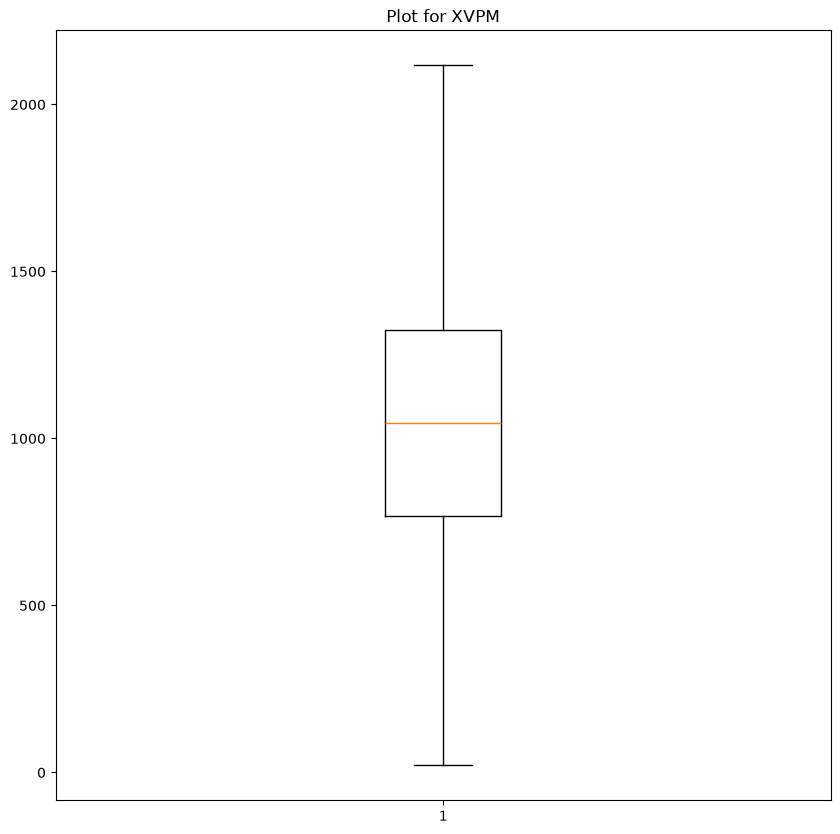

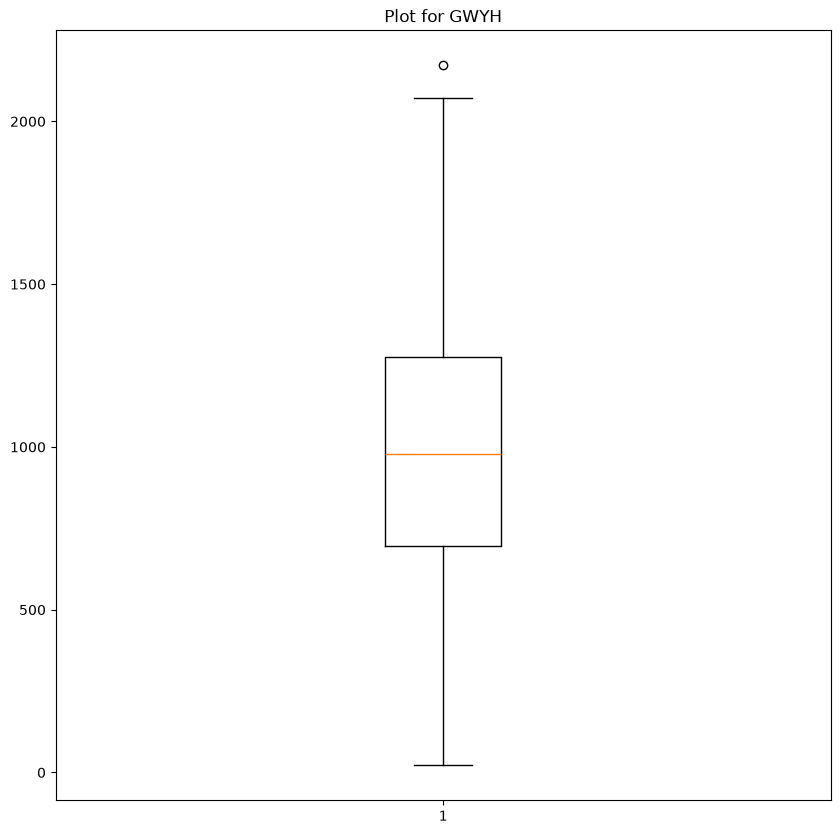

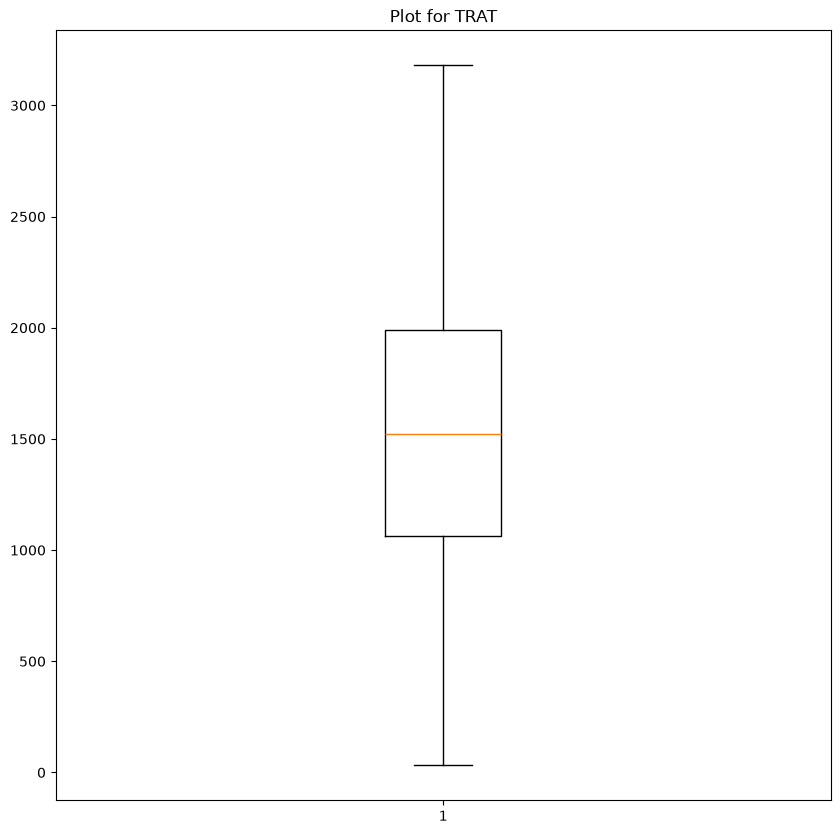

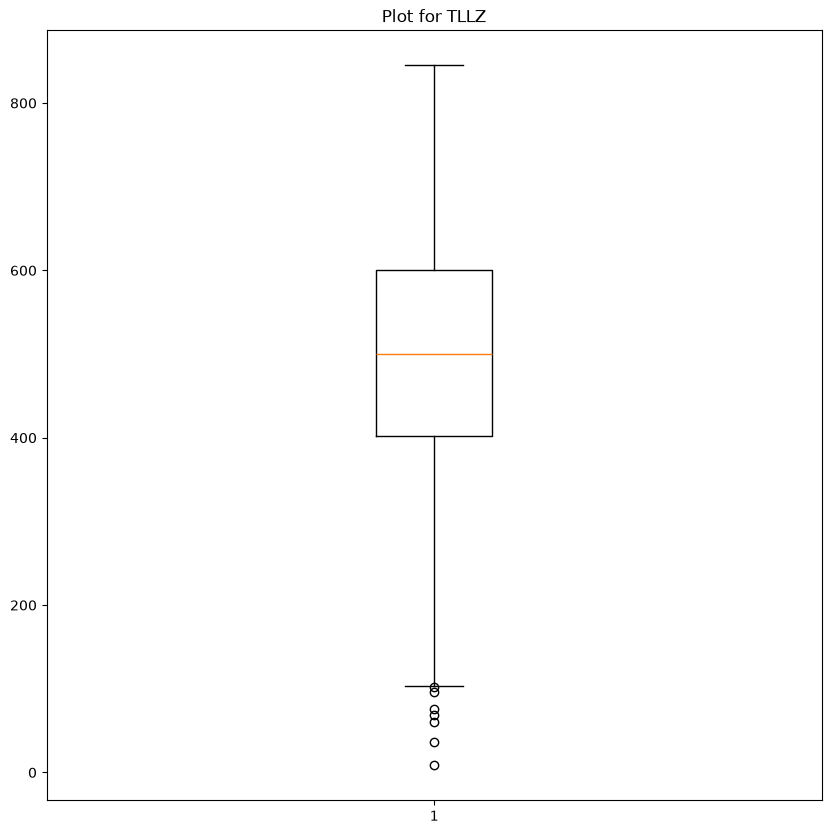

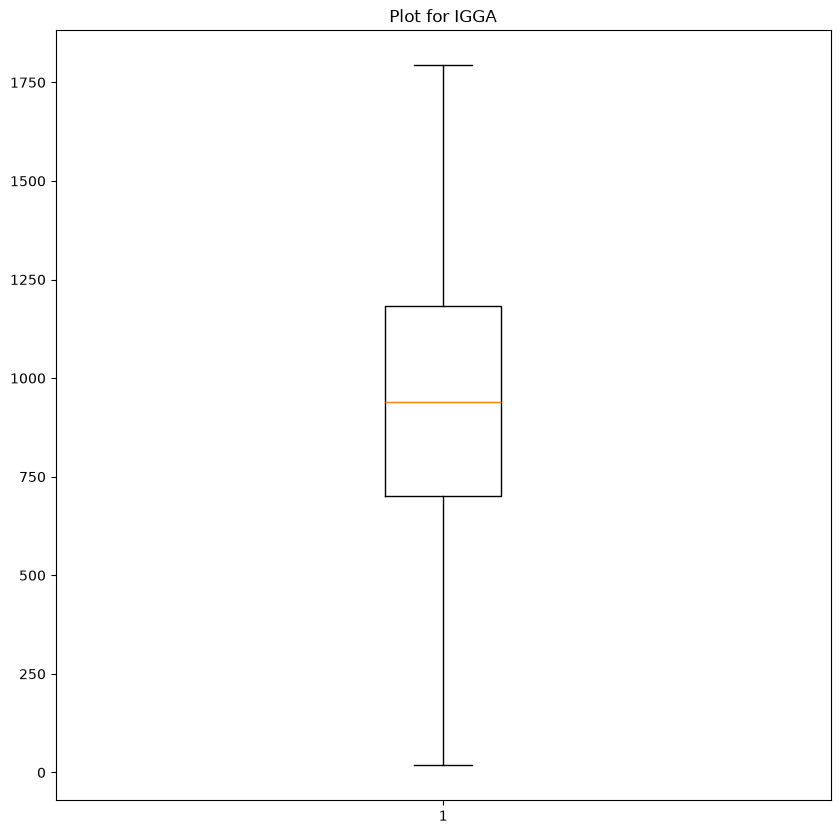

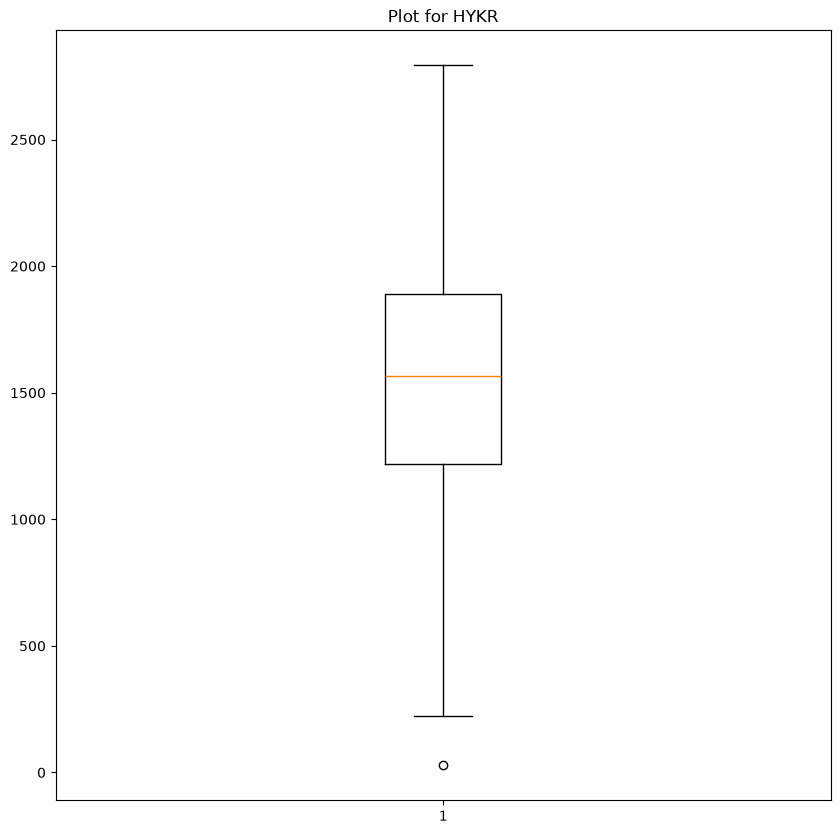

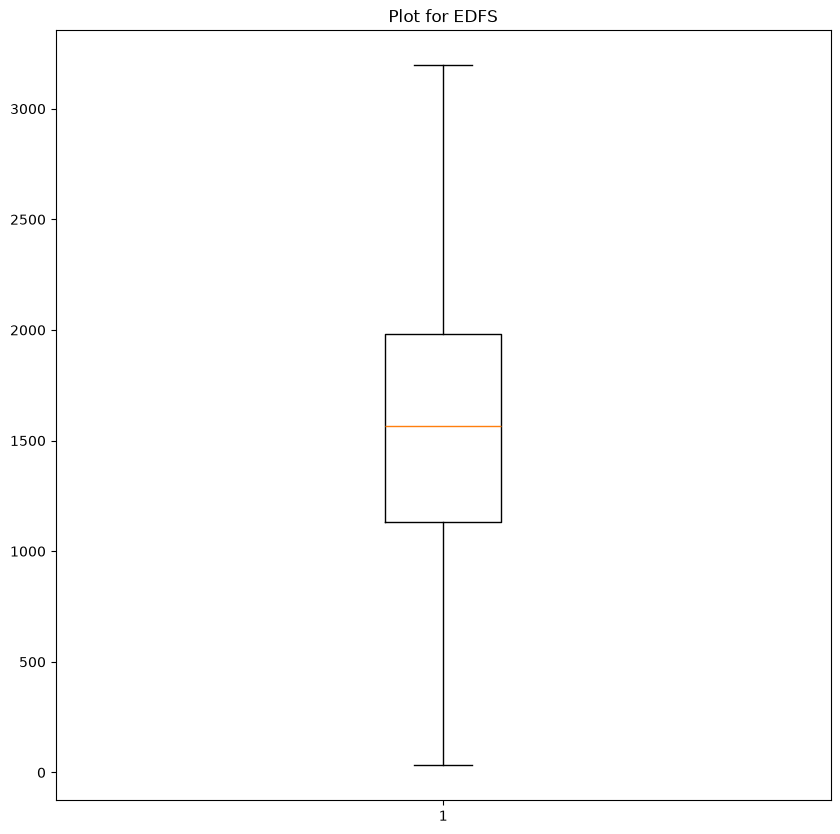

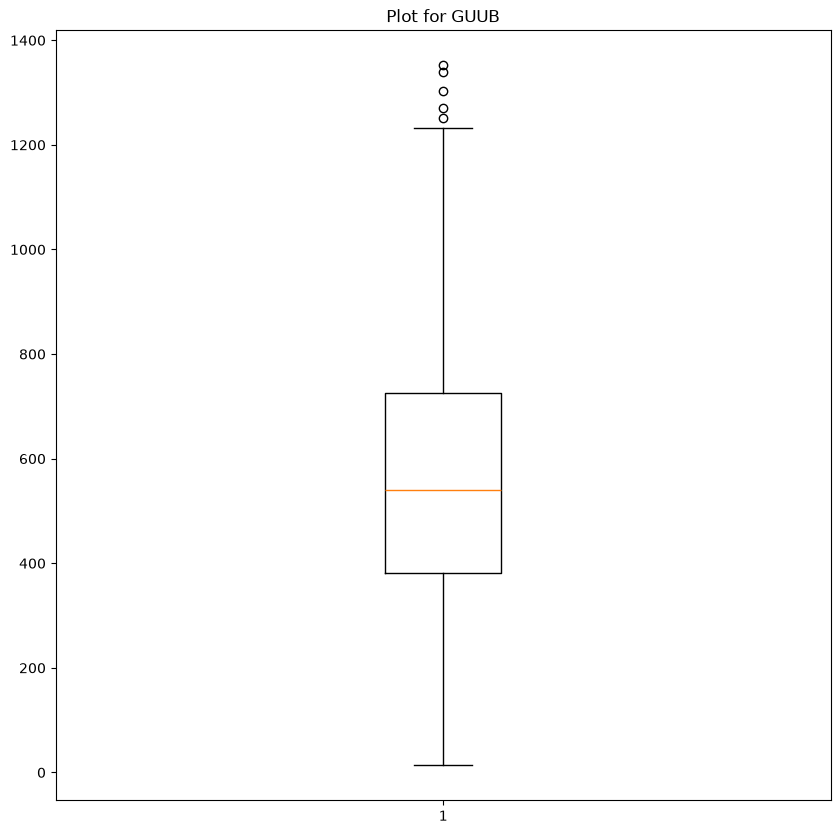

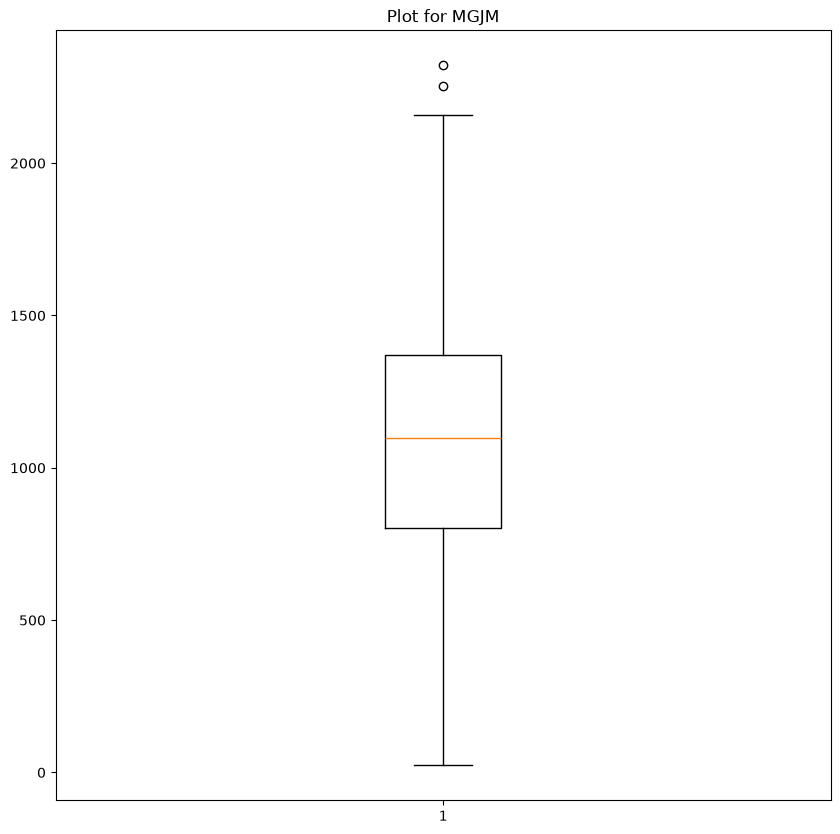

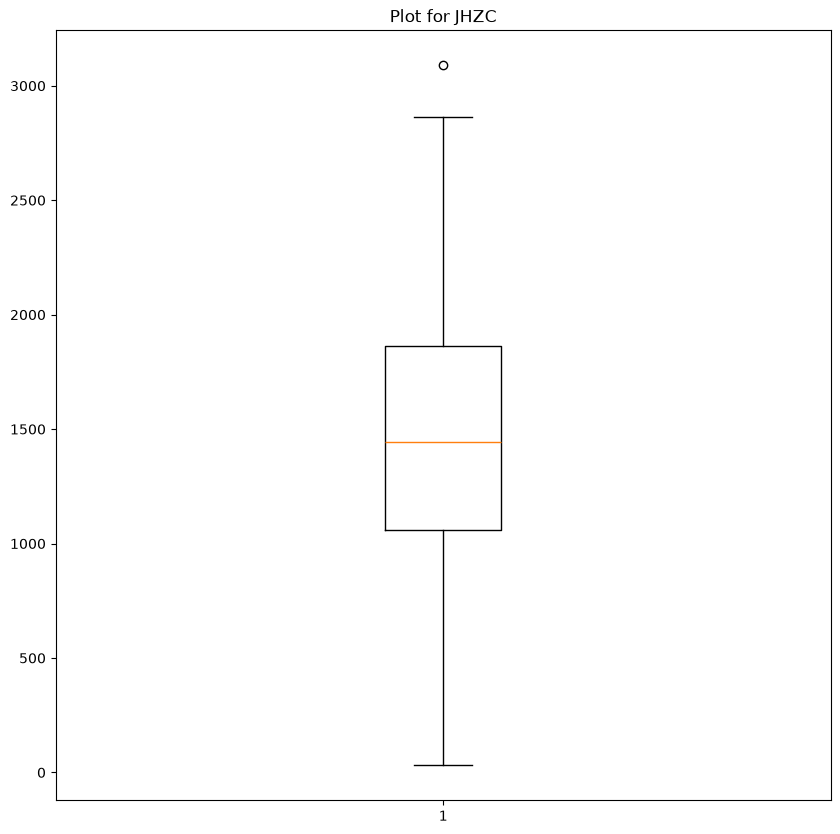

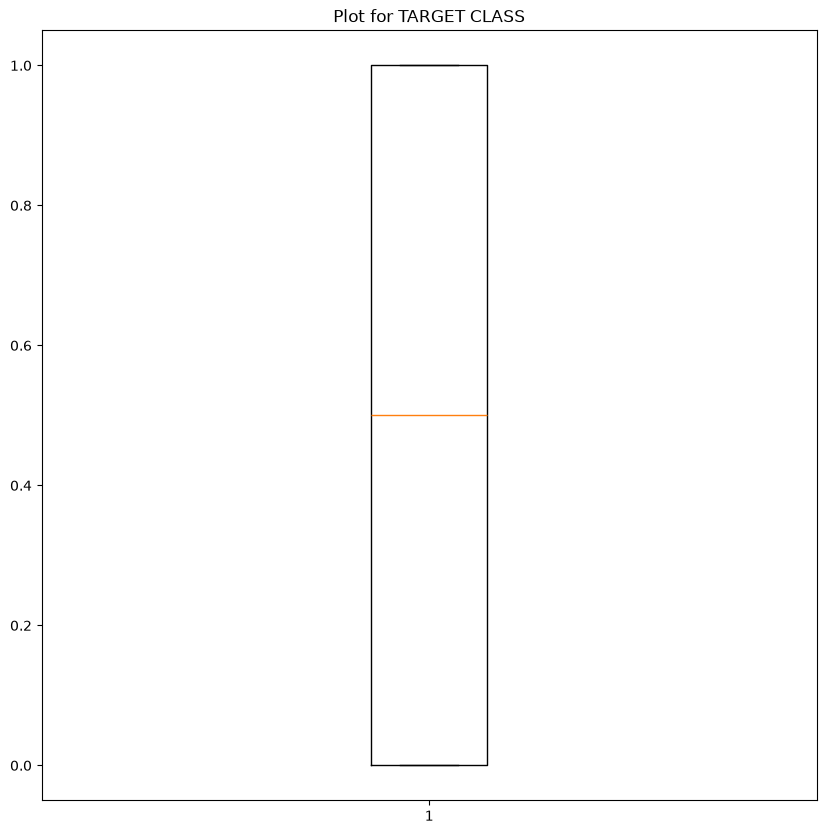

In [57]:
for col in NUMERICAL_COLUMN:
    plt.figure(figsize=FIGURE_SIZE)

    plt.boxplot(x=df[col])

    plt.title(f"Plot for {col}")
    plt.show()

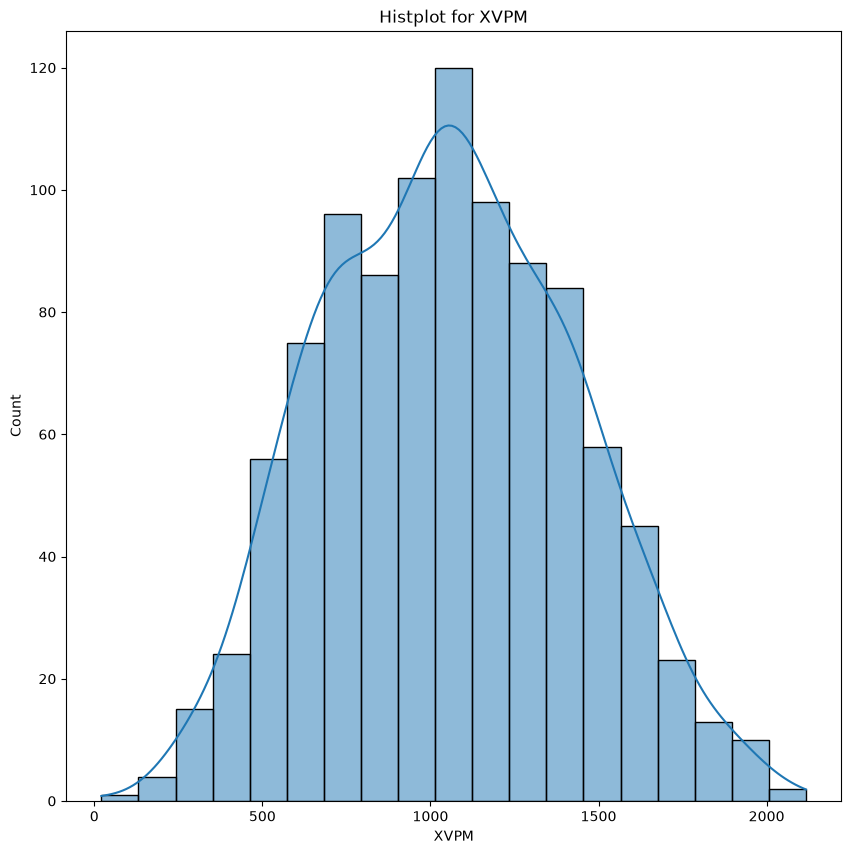

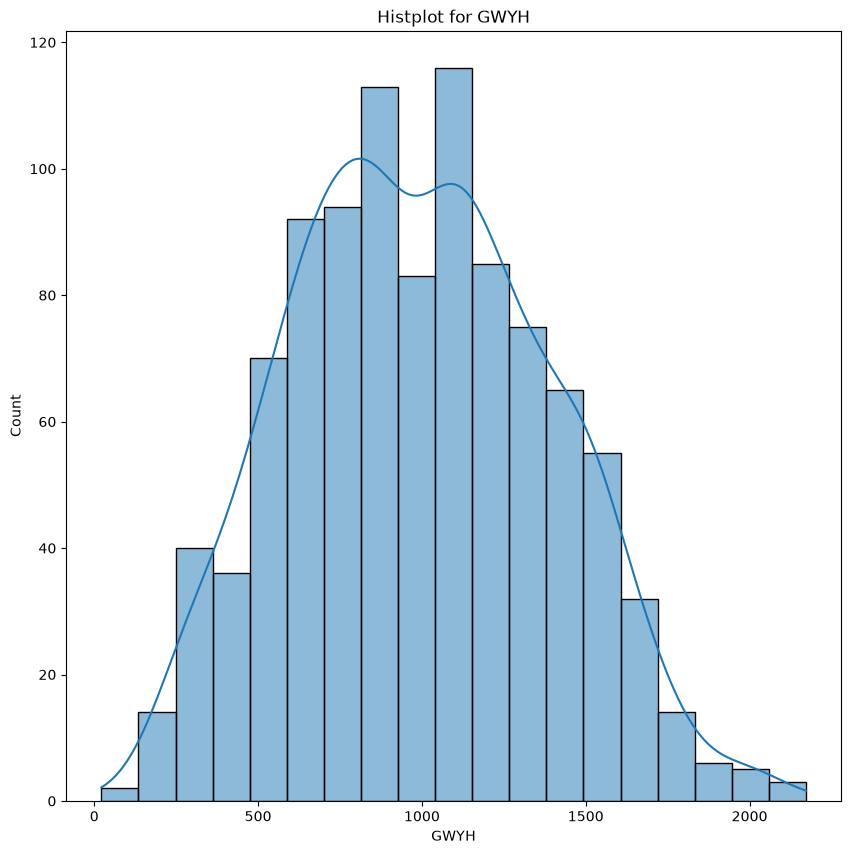

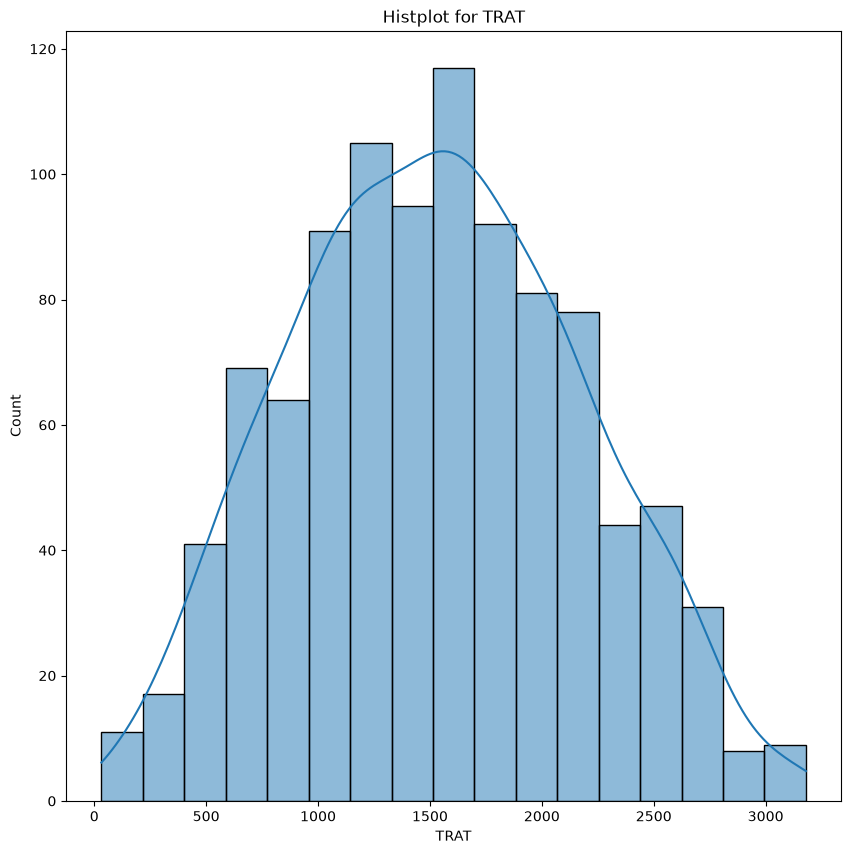

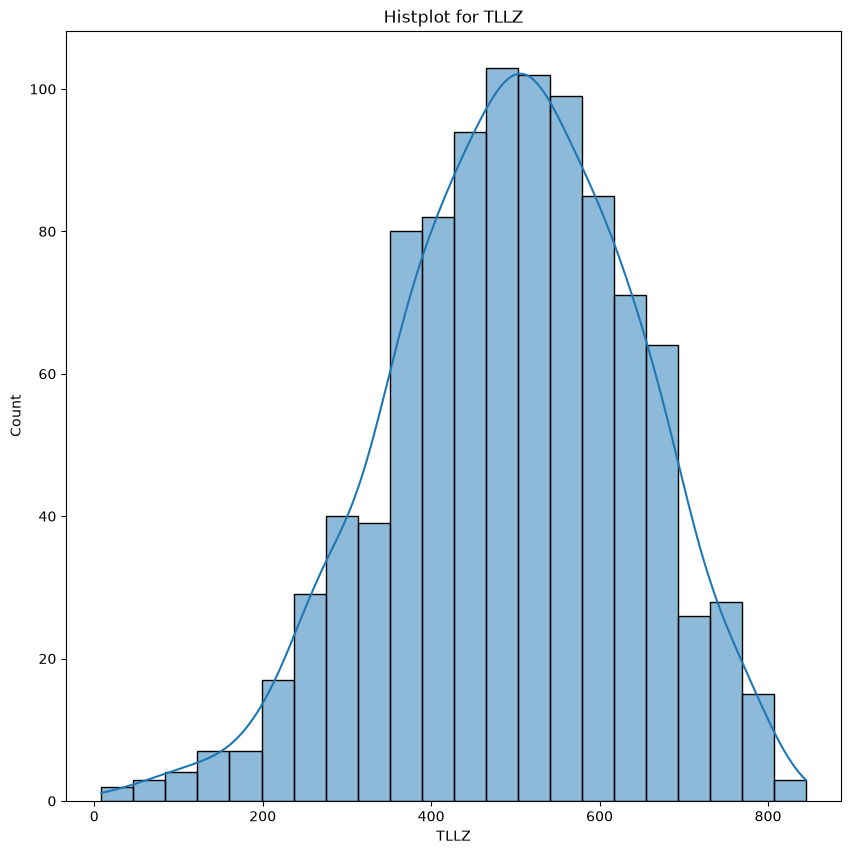

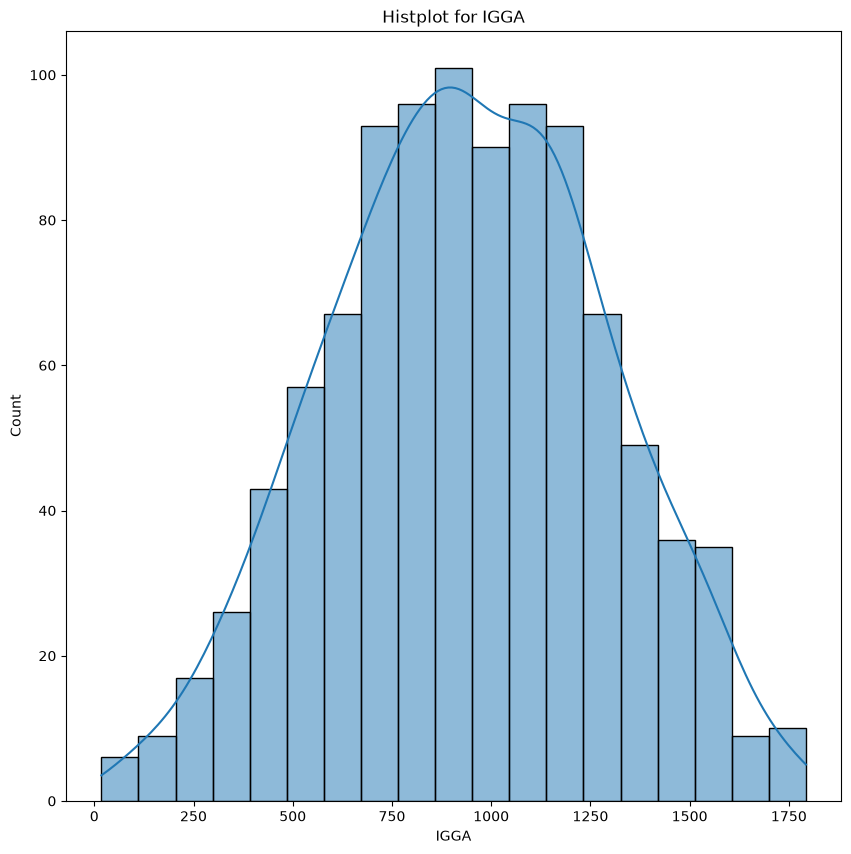

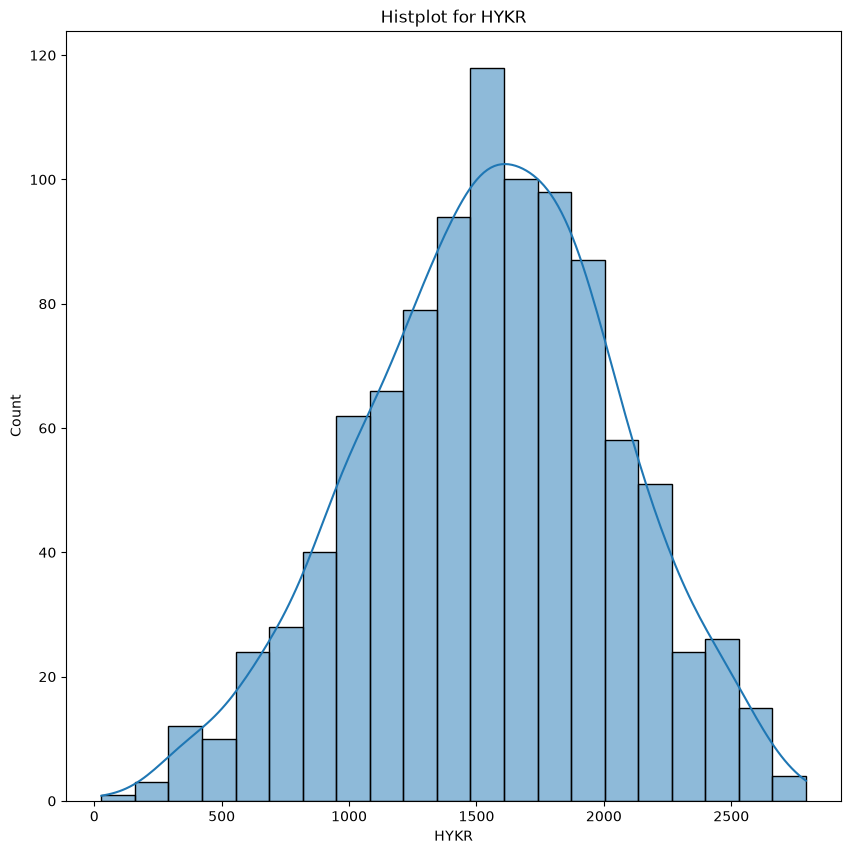

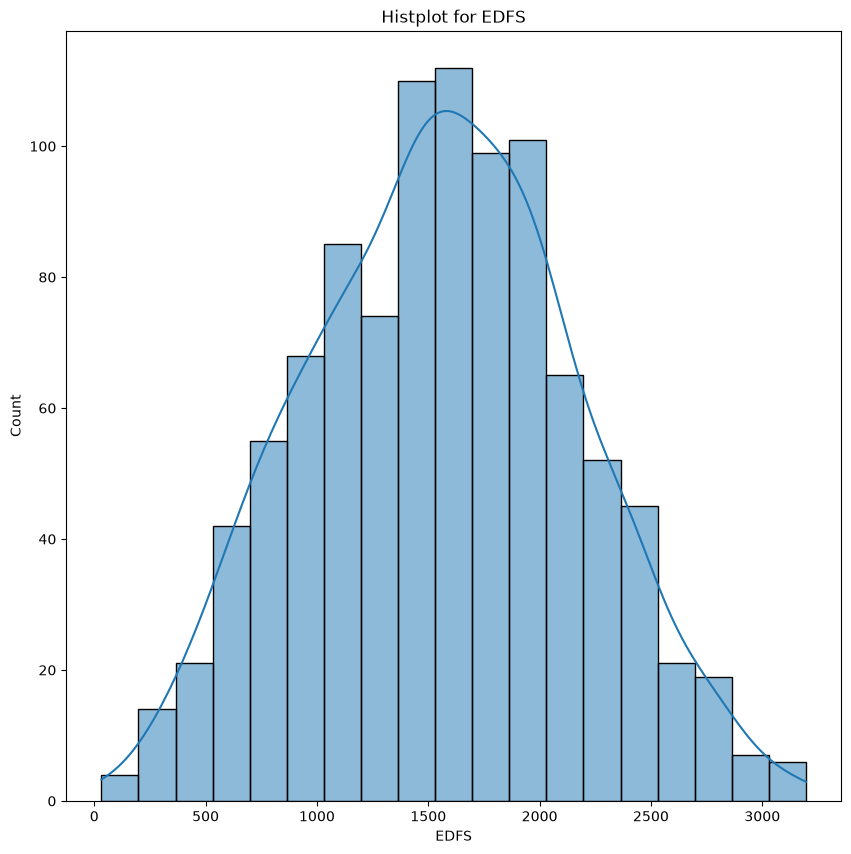

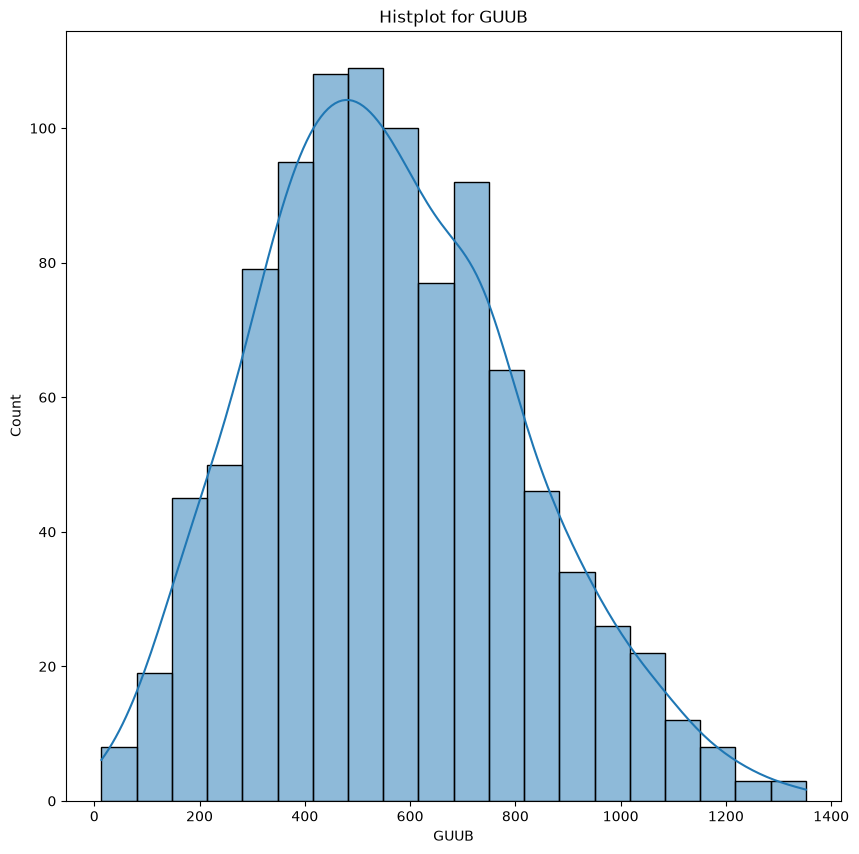

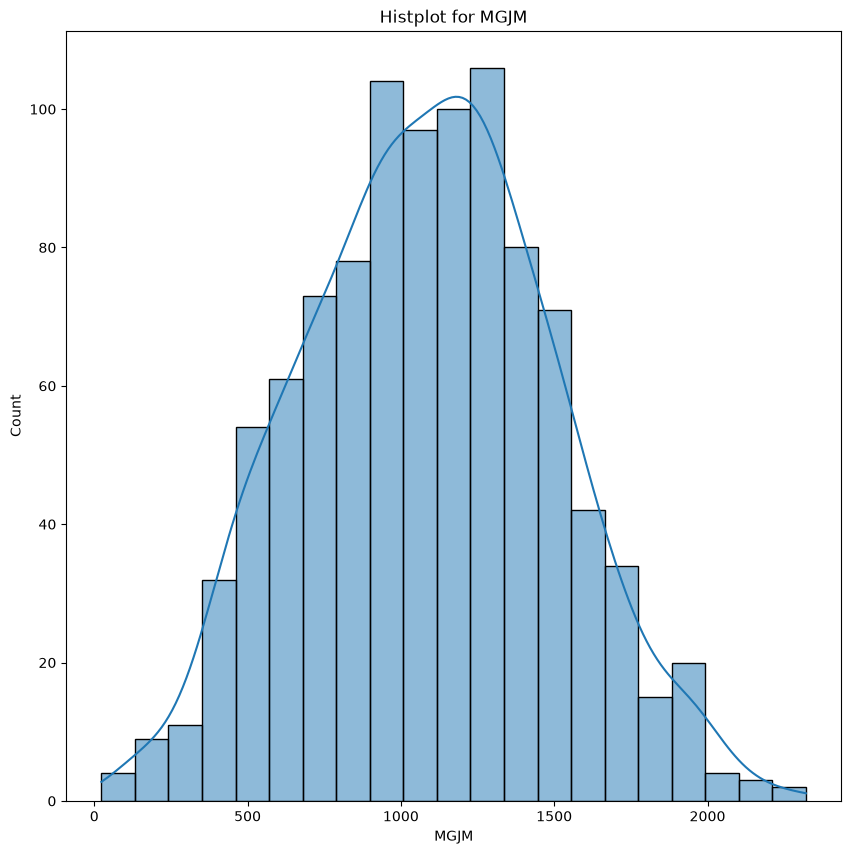

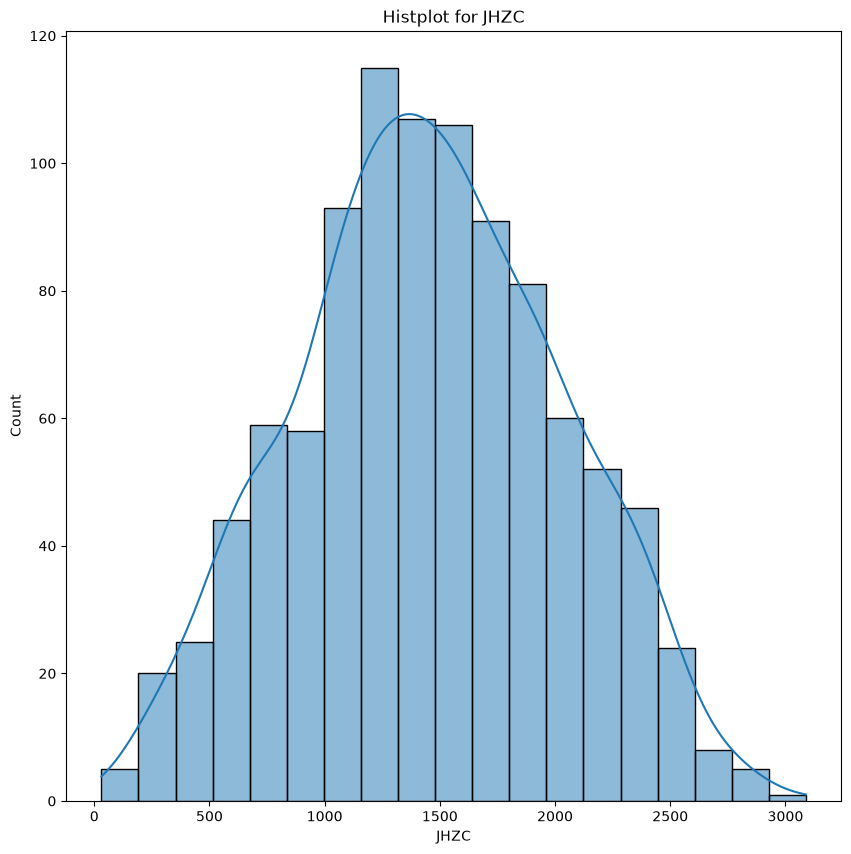

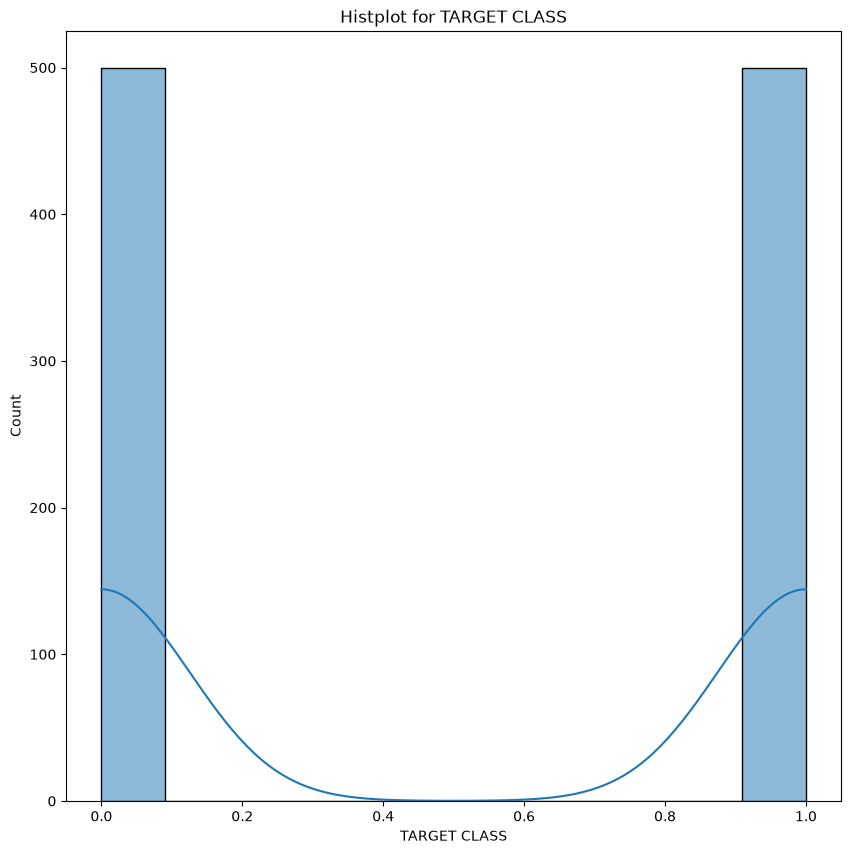

In [58]:
for col in NUMERICAL_COLUMN:
    plt.figure(figsize=FIGURE_SIZE)

    sns.histplot(df[col], kde=True)

    plt.title(f"Histplot for {col}")
    plt.show()

The distribution is pretty skewed so using IQR analysis to find the quantity of outlier and see how to handle them

In [59]:
iqr_counts = {}

for col in NUMERICAL_COLUMN:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    iqr_counts[col] = int(((df[col] < lower_limit) | (df[col] > upper_limit)).sum())

pd.DataFrame({ "IQR counts": iqr_counts })

,IQR counts
XVPM,0
GWYH,1
TRAT,0
TLLZ,7
IGGA,0
HYKR,1
EDFS,0
GUUB,5
MGJM,2
JHZC,1


Not handling the outliers as the count of the outliers is too puny so keeping them as it is.

## 8. Correlation analysis

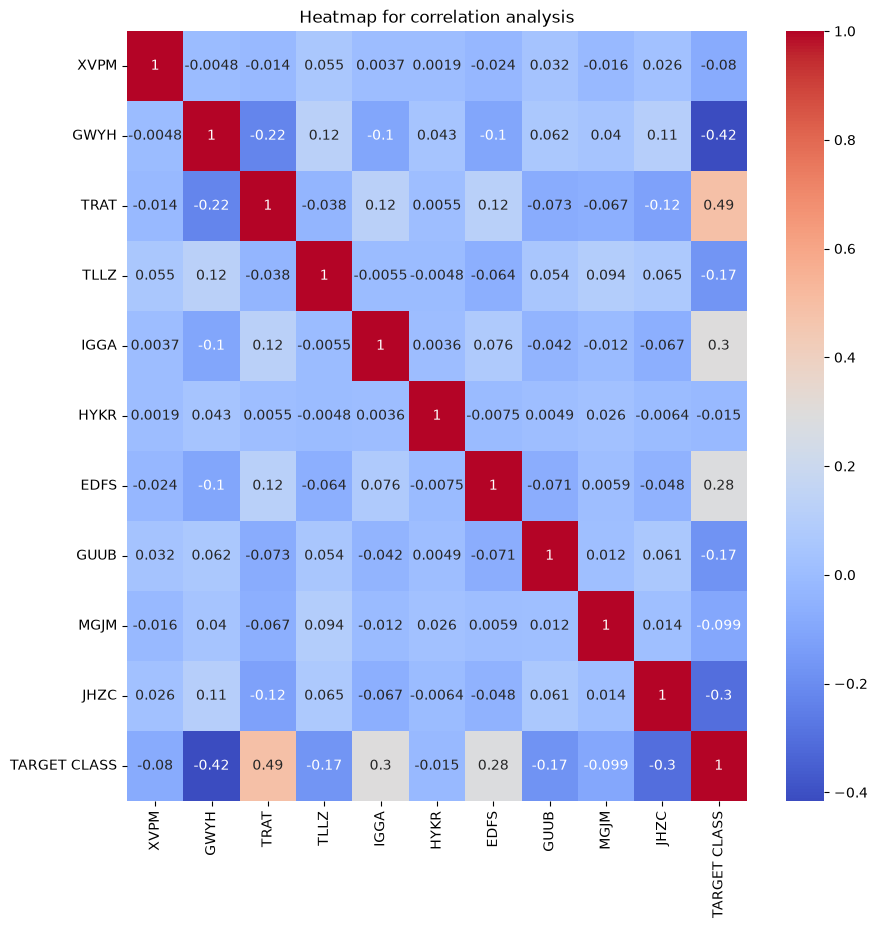

In [60]:
plot_correlation_heatmap(NUMERICAL_COLUMN)

There are no significant relations as per the heatmap, suggesting that the data might be synthetically generated 

## 9. Preparing the data for model training

In [61]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

In [63]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 10)
(200, 10)
(800,)
(200,)


## 10. Finding the optimal value of K using the error rates

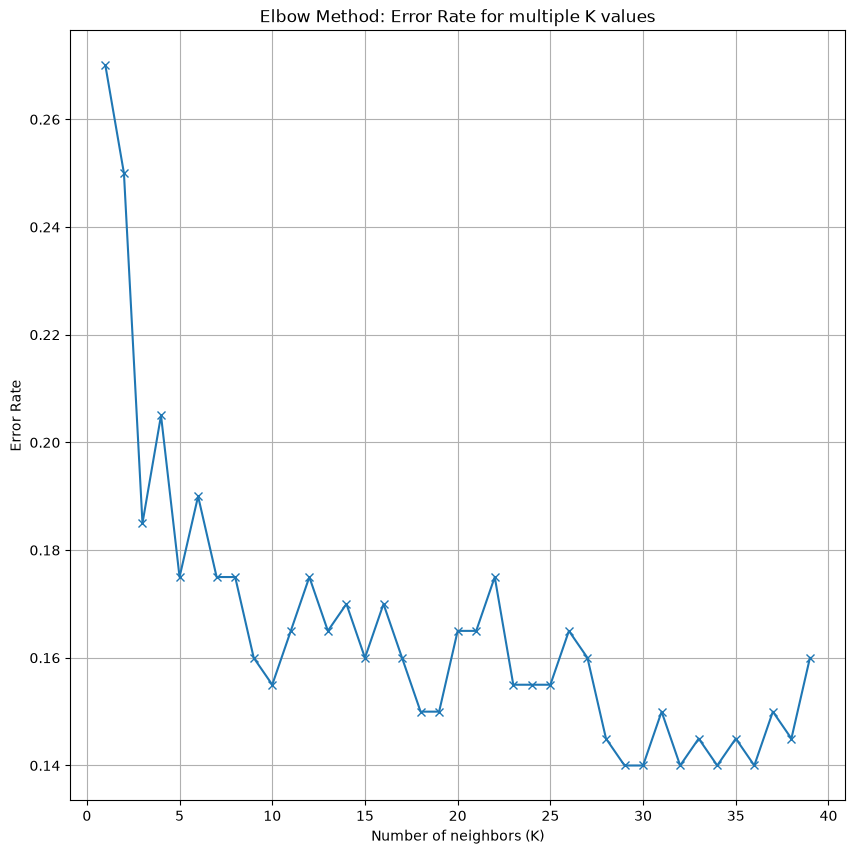

In [64]:
calculate_error_rate_score(X_train, X_test, y_train, y_test)

Choosing the value of K = 17 because the value of K is balanced at this point and there is a minimum error value than this but the difference is not too big so choosing the smaller number for better model training.

## 11. Creating the pipeline for preprocessing and model training (transformer -> estimator)

In [73]:
knn_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "knn",
            KNeighborsClassifier(**KNN_PARAMETERS)
        )
    ]
)

## 12. Fitting the split data to the pipeline 

In [74]:
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['XVPM','GWYH','TRAT',...,'GUUB','MGJM','JHZC']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 13. Evaluation of model parameters / model metrics

In [75]:
evaluate_model(knn_pipeline, X_test, y_test)

Accuracy score:  0.84

ROC AUC score:  0.9035

Confusion Matrix:
 [[82 18]
 [14 86]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.82      0.84       100
           1       0.83      0.86      0.84       100

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



## 14. Plot the feature importance curve

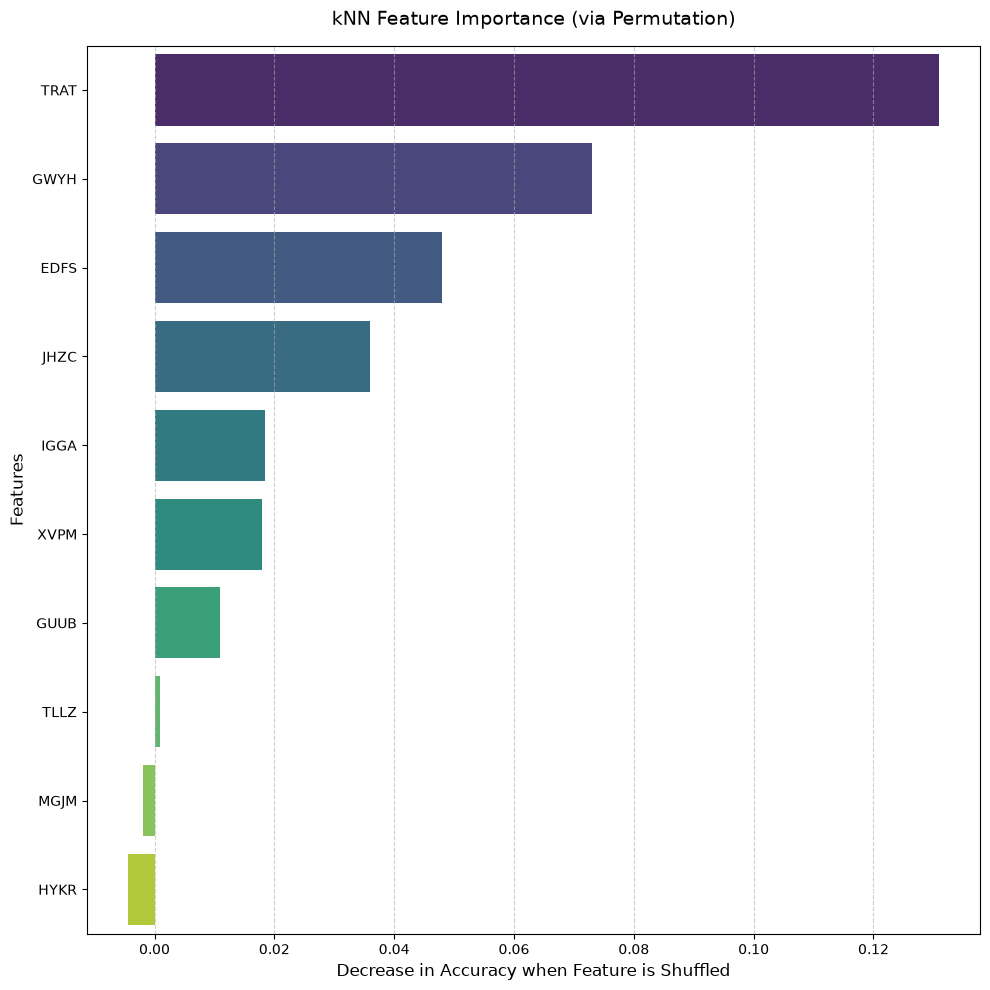

In [76]:
plot_feature_importance(knn_pipeline, X_test, y_test, X.columns)

## 15. Visualization of ROC curve

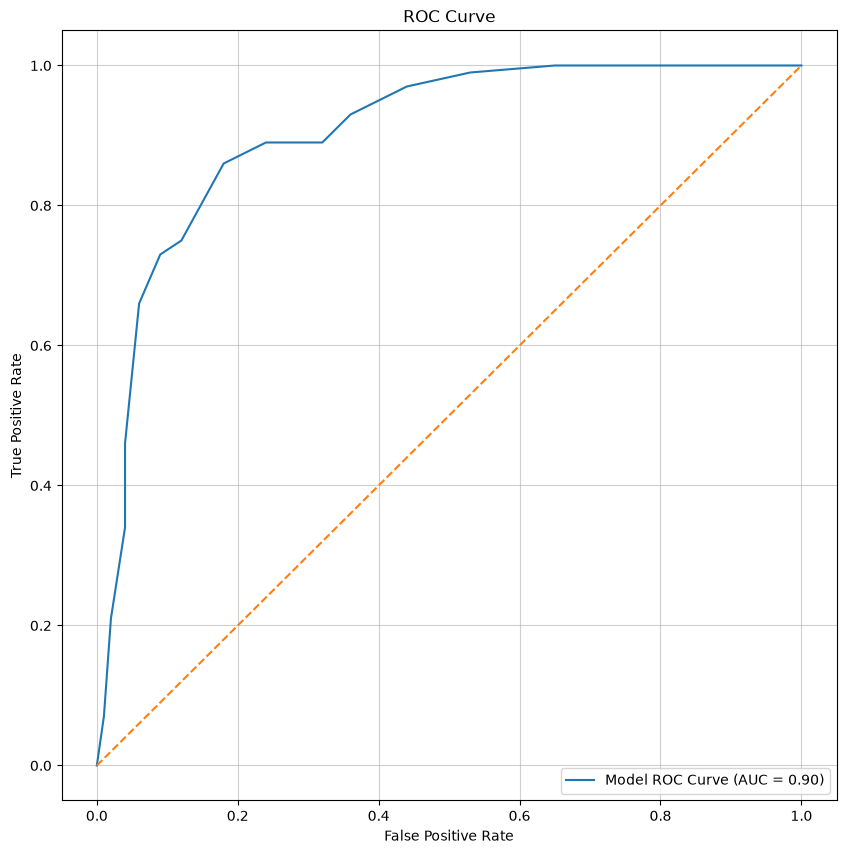

In [77]:
plot_roc_curve(knn_pipeline, X_test, y_test)

## 16. Calibration curve

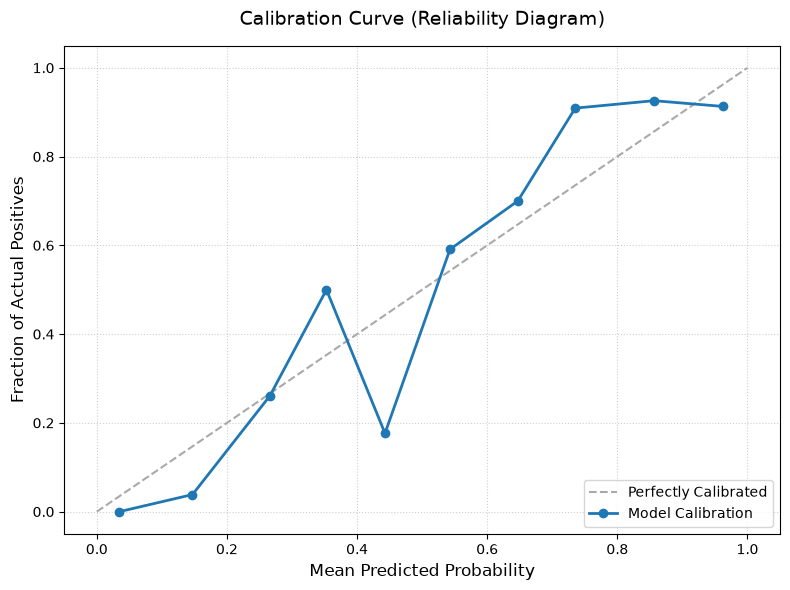

In [78]:
plot_calibration_curve(knn_pipeline, X_test, y_test)

## 17. Checking out the model predictions.

In [90]:
expected_columns = ['XVPM', 'GWYH', 'TRAT', 'TLLZ', 'IGGA', 'HYKR', 'EDFS', 'GUUB', 'MGJM', 'JHZC']

# 1. Create explicitly as DataFrames
df_low_profile = pd.DataFrame([{
    'XVPM': 767.41, 'GWYH': 694.86, 'TRAT': 1062.60, 'TLLZ': 401.79, 'IGGA': 700.76, 
    'HYKR': 1219.27, 'EDFS': 1132.10, 'GUUB': 381.70, 'MGJM': 801.85, 'JHZC': 1059.50
}])

df_high_profile = pd.DataFrame([{
    'XVPM': 1326.07, 'GWYH': 1275.53, 'TRAT': 1991.13, 'TLLZ': 600.53, 'IGGA': 1182.58, 
    'HYKR': 1891.94, 'EDFS': 1981.74, 'GUUB': 725.76, 'MGJM': 1369.92, 'JHZC': 1864.41
}])

df_out_of_scope = pd.DataFrame([{
    'XVPM': 10000.0, 'GWYH': 5000.0, 'TRAT': -50.0, 'TLLZ': 9999.0, 'IGGA': -500.0, 'HYKR': 8000.0, 
    'EDFS': 10000.0, 'GUUB': -100.0, 'MGJM': 9000.0, 'JHZC': 15000.0
}])

df_low_profile = df_low_profile[expected_columns]
df_high_profile = df_high_profile[expected_columns]
df_out_of_scope = df_out_of_scope[expected_columns]

In [91]:
prediction_example = {
    "low_profile": df_low_profile,
    "high_profile": df_high_profile,
    "out_of_scope": df_out_of_scope
}

In [92]:
display_prediction_example(knn_pipeline, prediction_example)


Scenario : low_profile
--------------------
     XVPM    GWYH    TRAT    TLLZ    IGGA     HYKR    EDFS   GUUB    MGJM  \
0  767.41  694.86  1062.6  401.79  700.76  1219.27  1132.1  381.7  801.85   

     JHZC  
0  1059.5  

Prediction (Target Class): 1

Scenario : high_profile
--------------------
      XVPM     GWYH     TRAT    TLLZ     IGGA     HYKR     EDFS    GUUB  \
0  1326.07  1275.53  1991.13  600.53  1182.58  1891.94  1981.74  725.76   

      MGJM     JHZC  
0  1369.92  1864.41  

Prediction (Target Class): 0

Scenario : out_of_scope
--------------------
      XVPM    GWYH  TRAT    TLLZ   IGGA    HYKR     EDFS   GUUB    MGJM  \
0  10000.0  5000.0 -50.0  9999.0 -500.0  8000.0  10000.0 -100.0  9000.0   

      JHZC  
0  15000.0  

Prediction (Target Class): 0
